# Desarrollo de modelos

En esta seccion se desarrollaran los modelos de prediccion para la investigacion. Al tener un problema de clasificacion, se trabajaran los siguientes modelos adicionales al modelo original. Estos modelos de clasificacion con algoritmos de optimizacion son los siguientes: 

 - KNN → KD-Trees, Ball Trees.
 - Naive Bayes → partial_fit() para entrenamiento por lotes.
 - XGBoost → tree_method='hist' y early_stopping_rounds.
 - SVM → SGD SVM (SGDClassifier) , LinearSVC en vez de SVC(kernel='linear'), RBF con Random Fourier Features

En las siguientes lineas de codigo, se encontrara el desarrollo de los modelos.

In [3]:
import pandas as pd
df = pd.read_csv("metricas_camiones.csv")

Cargamos los datos Pre-procesados para el desarrollo de los modelos.

## Modelo KNN

En las siguientes lineas de codigos, aplicaremos los modelos KD-Trees, Ball Trees.

Las librerias utilizadas para el **modelo de KNN** y para el desarrollo de modelos se encuentran a continuacion.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, recall_score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score,train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter, defaultdict
import time
from sklearn.metrics import roc_curve, roc_auc_score

##### Definicion de modelo e hiperparametros

En el siguiente codigo definimos el dataset en la variable de respuesta *Y* y las variables predictoras *X* seguido de la definicon del modelo y escalamiento de las variables predictoras en un Pipeline y la rejilla de bsuqueda Param_grid para los hiperparaemtros del modelo. A su vez definimos el Cross Validation que se usara para los Inner y outer loops del nested cross validation. En este caso sera el Stratified CV. 

In [317]:
# Definir variables predictoras y objetivo
X = df.drop(columns=["Equipo", "Suspension", "Falla"])  # Ajusta según tus datos
y = df["Falla"]

# Crear pipeline con escalado y clasificador KNN
pipe = make_pipeline(StandardScaler(), KNeighborsClassifier())

# Definir hiperparámetros para GridSearch
param_grid = {
    "kneighborsclassifier__n_neighbors": [3, 4, 5, 6, 7,8,9, 10],
    "kneighborsclassifier__weights": ["distance"],
    "kneighborsclassifier__metric": ["euclidean"],
    "kneighborsclassifier__algorithm": ["ball_tree", "kd_tree"]
}

# Definir Nested Cross-Validation
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


Se realiza una validación cruzada anidada. En cada fold externo, se divide el dataset en entrenamiento y prueba. Al conjunto de entrenamiento se le aplica SMOTE para balancear las clases. Luego, se usa GridSearchCV con validación interna para encontrar los mejores hiperparámetros. El modelo optimizado se evalúa en el conjunto de prueba y se guardan predicciones, probabilidades, puntuaciones y los hiperparámetros seleccionados.

In [ ]:
# Variables para guardar resultados
all_y_true = []
all_y_pred = []
all_y_scores = []
nested_scores = []
best_params_list = []  # Guardamos los mejores hiperparámetros en cada iteración
processing_times = []

# Diccionario para tiempos por tipo de algoritmo
algorithm_times = defaultdict(list)

# Iterar sobre los folds de la validación externa
for fold_idx, (train_idx, test_idx) in enumerate(cv_outer.split(X, y), 1):
    start_time = time.time()
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Aplicar SMOTE a los datos de entrenamiento
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Aplicar GridSearchCV dentro de cada fold
    grid_search = GridSearchCV(pipe, param_grid, cv=cv_inner, scoring="recall", n_jobs=-1)
    grid_search.fit(X_train_res, y_train_res) 

    # Guardar los mejores hiperparámetros de esta iteración
    best_params_list.append(frozenset(grid_search.best_params_.items()))

    # Obtener el mejor modelo y hacer predicciones en el conjunto de prueba
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_scores = best_model.predict_proba(X_test)[:, 1]  # Probabilidad de la clase positiva

    # Guardar resultados
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_scores.extend(y_scores)
    nested_scores.append(grid_search.best_score_)
    
         # Guardar tiempo por fold
    end_time = time.time()
    elapsed_time = end_time - start_time
    processing_times.append(elapsed_time)
    print(f"⏳ Tiempo total del fold {fold_idx}: {elapsed_time:.2f} segundos")

    # Medir tiempo promedio por tipo de algoritmo en GridSearch interna
    results = grid_search.cv_results_
    for mean_time, params in zip(results["mean_fit_time"], results["params"]):
        algorithm = params["kneighborsclassifier__algorithm"]
        algorithm_times[algorithm].append(mean_time)

⏳ Tiempo total del fold 1: 0.09 segundos
⏳ Tiempo total del fold 2: 0.04 segundos
⏳ Tiempo total del fold 3: 0.03 segundos
⏳ Tiempo total del fold 4: 0.03 segundos
⏳ Tiempo total del fold 5: 0.04 segundos


Se obtienen los tiempos de procesamiento de cada *Outer loop*

#### Desbalanceo de datos - SMOTE

Al tener los datos desbalaneados, En el siguiente codigo observamos el cambio de **SMOTE** a los datos de entrenamiento.

In [319]:
# Verificar distribución antes de SMOTE
print("Distribución antes de SMOTE:")
print(y_train.value_counts())

# Verificar distribución después de SMOTE
print("\nDistribución después de SMOTE:")
print(y_train_res.value_counts())

Distribución antes de SMOTE:
1    10
0     7
Name: Falla, dtype: int64

Distribución después de SMOTE:
0    10
1    10
Name: Falla, dtype: int64


En este codigo, se presentan los resultados del modelo con los mejores hiperparametros encontrados durante el entrenamiento.

In [320]:
# Encontrar los hiperparámetros más frecuentes
best_overall_params = Counter(best_params_list).most_common(1)[0][0]
best_overall_params = dict(best_overall_params)  # Convertimos de nuevo a diccionario

# Tiempo promedio por tipo de algoritmo
print("\n📊 Tiempo promedio por tipo de algoritmo:")
for algorithm, times in algorithm_times.items():
    avg_time = sum(times) / len(times)
    print(f"🔧 '{algorithm}': {avg_time:.4f} segundos (promedio en {len(times)} ejecuciones)")

# Eliminamos los prefijos 
best_params = {k.replace("kneighborsclassifier__", ""): v for k, v in best_overall_params.items()}

print("Mejores hiperparámetros globales:", best_params)


📊 Tiempo promedio por tipo de algoritmo:
🔧 'ball_tree': 0.0015 segundos (promedio en 40 ejecuciones)
🔧 'kd_tree': 0.0014 segundos (promedio en 40 ejecuciones)
Mejores hiperparámetros globales: {'metric': 'euclidean', 'algorithm': 'ball_tree', 'weights': 'distance', 'n_neighbors': 3}


Observamos que el mejor procesamiento de tiempo lo obtuvo el algoritmo *"KD Tree"*. sin embargo, el mejor despempeno lo obtuvo el *"Ball Tree"* en las metricas de evaluacion. 

#### Matriz de Confusión y metricas de desempeno

En el siguiente codigo, observamos el desempeno del modelo a lo largo de cada **outer Fold**. El numero de pliegues seleccioando para el K-fold externo fue de 5 y los pliegues para el CV interno fue de 3. Esta matriz de confusion y las metricas calculadas vienen de los resultados del **test** cada pliegue externo a la vez que la curva ROC y valor de AUC.

En el siguiente codigo se observa la matriz de Confusión

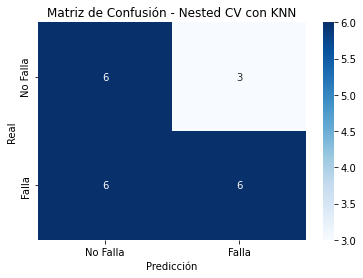

In [321]:
# Matriz de Confusión
conf_matrix = confusion_matrix(all_y_true, all_y_pred)

# Visualizar la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Falla", "Falla"], yticklabels=["No Falla", "Falla"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Nested CV con KNN")
plt.show()


En el siguiente se observaran los valores de las metricas de desempeno. Para la investigacion, la metrica con la que se evaluara cada uno de los modelos sera el Recall. 

In [322]:
# Evaluación final
print("Nested CV Scores: ", nested_scores)
print("Mean Accuracy: {:.4f} ± {:.4f}".format(np.mean(nested_scores), np.std(nested_scores)))

# Reporte de clasificación
print("Reporte de clasificación:\n", classification_report(all_y_true, all_y_pred))

Nested CV Scores:  [0.7746031746031745, 0.6333333333333333, 0.6626984126984127, 0.8023809523809525, 0.8412698412698413]
Mean Accuracy: 0.7429 ± 0.0808
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.50      0.67      0.57         9
           1       0.67      0.50      0.57        12

    accuracy                           0.57        21
   macro avg       0.58      0.58      0.57        21
weighted avg       0.60      0.57      0.57        21



#### Curva ROC y metrica AUC

observamos la curva y el valor obtenido a lo largo del nested CV del AUC

AUC Score: 0.7315


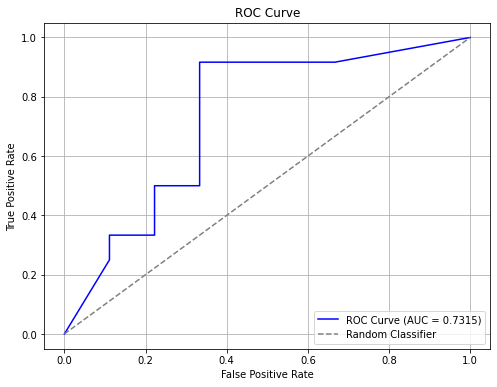

In [323]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calcular AUC
auc_score = roc_auc_score(all_y_true, all_y_scores)
print(f"AUC Score: {auc_score:.4f}")

# Calcular puntos de la curva ROC
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_scores)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

En el código anterior completo, se muestra la implementación del modelo K-Nearest Neighbors (KNN), utilizando una combinación de *ParamGrid*, *GridSearchCV* y un *Pipeline* para estructurar el flujo de trabajo. La validación empleada fue **Nested Cross-Validation**, una variante del método K-Fold Cross-Validation recomendada en diversos estudios para conjuntos de datos con muestras pequeñas, ya que permite una evaluación más robusta y menos propensa al sobreajuste.

La implementación de Nested CV fue realizada de forma manual. Tanto para el inner como para el outer loop, se utilizó el método **StratifiedKFold**, ya que la variable de respuesta *Y* es binaria y presenta una distribución que podría sesgar el aprendizaje del modelo si no se estratifica adecuadamente. Esta elección asegura que cada partición conserve la proporción de clases, lo cual es crucial para una correcta identificación de patrones por parte del modelo.

Este mismo procedimieto se realizara a cada uno de los modelos que se desarrollaran en esta investigación.

## Clasificador Bayesiano

En las siguientes lineas de codigos, aplicaremos el modelo de Naive Bayes. Se realiza un modelo realizando *fit()* y *partial_fit()* para determinar el mejor modelo.

#### Entrenamiento del modelo

In [ ]:
from sklearn.naive_bayes import GaussianNB

# Crear pipeline con escalado y clasificador KNN
pipe = make_pipeline(StandardScaler(), GaussianNB())

# Definir hiperparámetros para GridSearch
# 📊 Definir hiperparámetros para GridSearch
param_grid = {
    'gaussiannb__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]  # Controla la suavización para evitar valores extremos
}

# Variables para guardar resultados
all_y_true = []
all_y_pred = []
all_y_scores = []
nested_scores = []
best_params_list = []  # Guardamos los mejores hiperparámetros en cada iteración
processing_times = []

# Diccionario para tiempos por tipo de algoritmo
algorithm_times = defaultdict(list)

# Iterar sobre los folds de la validación externa
for fold_idx, (train_idx, test_idx) in enumerate(cv_outer.split(X, y), 1):
    start_time = time.time()
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Aplicar SMOTE a los datos de entrenamiento
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Aplicar GridSearchCV dentro de cada fold
    grid_search = GridSearchCV(pipe, param_grid, cv=cv_inner, scoring="recall", n_jobs=-1)
    grid_search.fit(X_train_res, y_train_res)  

    # Guardar los mejores hiperparámetros de esta iteración
    best_params_list.append(frozenset(grid_search.best_params_.items()))

    # Obtener el mejor modelo y hacer predicciones en el conjunto de prueba
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_scores = best_model.predict_proba(X_test)[:, 1]  # Probabilidad de la clase positiva

    # Guardar resultados
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_scores.extend(y_scores)
    nested_scores.append(grid_search.best_score_)
    
             # Guardar tiempo por fold
    end_time = time.time()
    elapsed_time = end_time - start_time
    processing_times.append(elapsed_time)
    print(f"⏳ Tiempo total del fold {fold_idx}: {elapsed_time:.2f} segundos")

    # Medir tiempo promedio por tipo de algoritmo en GridSearch interna
    results = grid_search.cv_results_
    for mean_time, params in zip(results["mean_fit_time"], results["params"]):
        algorithm = params["gaussiannb__var_smoothing"]
        algorithm_times[algorithm].append(mean_time)


⏳ Tiempo total del fold 1: 0.04 segundos
⏳ Tiempo total del fold 2: 0.02 segundos
⏳ Tiempo total del fold 3: 0.02 segundos
⏳ Tiempo total del fold 4: 0.02 segundos
⏳ Tiempo total del fold 5: 0.02 segundos


En el siguiente codigo observamos los tiempos de procesamiento por parametro.

In [325]:
# Encontrar los hiperparámetros más frecuentes
best_overall_params = Counter(best_params_list).most_common(1)[0][0]
best_overall_params = dict(best_overall_params)  # Convertimos de nuevo a diccionario

# Tiempo promedio por tipo de algoritmo
print("\n📊 Tiempo promedio por tipo de algoritmo:")
for algorithm, times in algorithm_times.items():
    avg_time = sum(times) / len(times)
    print(f"Smoothing '{algorithm}': {avg_time:.4f} segundos (promedio en {len(times)} ejecuciones)")

# Eliminamos los prefijos 
best_params = {k.replace("gaussiannb__", ""): v for k, v in best_overall_params.items()}

print("Mejores hiperparámetros globales:", best_params)


📊 Tiempo promedio por tipo de algoritmo:
Smoothing '1e-09': 0.0017 segundos (promedio en 5 ejecuciones)
Smoothing '1e-08': 0.0016 segundos (promedio en 5 ejecuciones)
Smoothing '1e-07': 0.0018 segundos (promedio en 5 ejecuciones)
Smoothing '1e-06': 0.0012 segundos (promedio en 5 ejecuciones)
Smoothing '1e-05': 0.0011 segundos (promedio en 5 ejecuciones)
Mejores hiperparámetros globales: {'var_smoothing': 1e-09}


#### Matriz de Confusión y metricas de desempeno

Nested CV Scores:  [0.5301587301587302, 0.5238095238095238, 0.6999999999999998, 0.6984126984126985, 0.7936507936507936]
Mean Accuracy: 0.6492 ± 0.1056


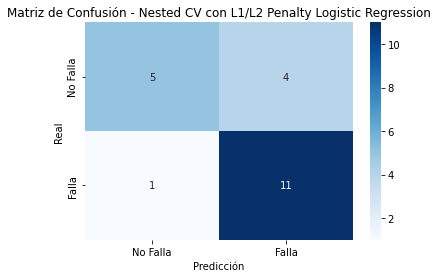

In [326]:
# Mostrar resultados de Nested Cross-Validation
print("Nested CV Scores: ", nested_scores)
print("Mean Accuracy: {:.4f} ± {:.4f}".format(np.mean(nested_scores), np.std(nested_scores)))

# Matriz de Confusión
conf_matrix = confusion_matrix(all_y_true, all_y_pred)

# Visualizar la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Falla", "Falla"], yticklabels=["No Falla", "Falla"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Nested CV con L1/L2 Penalty Logistic Regression")
plt.show()


En el siguiente codigo se presentan los resultados obtenidos.

In [328]:
# Métricas adicionales
print("Reporte de clasificación:\n", classification_report(all_y_true, all_y_pred))

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.83      0.56      0.67         9
           1       0.73      0.92      0.81        12

    accuracy                           0.76        21
   macro avg       0.78      0.74      0.74        21
weighted avg       0.78      0.76      0.75        21



#### Curva ROC y AUC

AUC Score: 0.5278


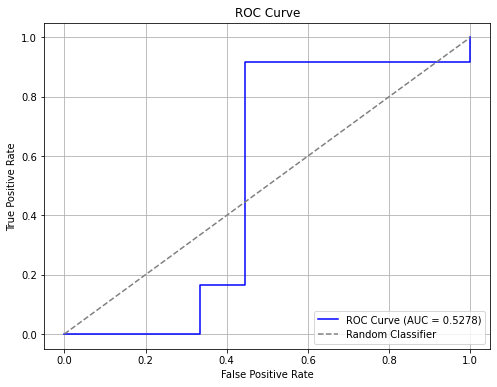

In [329]:
# Calcular AUC
auc_score = roc_auc_score(all_y_true, all_y_scores)
print(f"AUC Score: {auc_score:.4f}")

# Calcular puntos de la curva ROC
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_scores)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#### Implementando Partial_fit()

A continuacion se encontrara el codigo implementando el algoritmo *partial_fit()*

In [330]:
# Hiperparámetros a probar
param_grid = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]

# Variables para guardar resultados
all_y_true = []
all_y_pred = []
all_y_scores = []
nested_scores = []
best_params_list = []
processing_times = []
algorithm_times = defaultdict(list)

# Bucle externo
for fold_idx, (train_idx, test_idx) in enumerate(cv_outer.split(X, y), 1):
    start_time = time.time()
    X_train_outer, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train_outer, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Aplicar SMOTE
    smote = SMOTE(random_state=42)
    X_train_outer_res, y_train_outer_res = smote.fit_resample(X_train_outer, y_train_outer)

    best_score = -np.inf
    best_param = None

    # Búsqueda de hiperparámetros en inner loop
    for var_smoothing in param_grid:
        inner_scores = []

        for inner_train_idx, inner_val_idx in cv_inner.split(X_train_outer_res, y_train_outer_res):
            X_train_inner = X_train_outer_res.iloc[inner_train_idx]
            y_train_inner = y_train_outer_res.iloc[inner_train_idx]
            X_val = X_train_outer_res.iloc[inner_val_idx]
            y_val = y_train_outer_res.iloc[inner_val_idx]

            model = GaussianNB(var_smoothing=var_smoothing)
            model.partial_fit(X_train_inner, y_train_inner, classes=np.unique(y))  # Entrenamiento por lote

            y_val_pred = model.predict(X_val)
            recall = recall_score(y_val, y_val_pred)
            inner_scores.append(recall)

        avg_score = np.mean(inner_scores)
        algorithm_times[var_smoothing].append(np.mean(inner_scores))  # usamos score como "proxy de tiempo"

        if avg_score > best_score:
            best_score = avg_score
            best_param = var_smoothing

    # Entrenar modelo final con mejor parámetro
    final_model = GaussianNB(var_smoothing=best_param)
    final_model.partial_fit(X_train_outer_res, y_train_outer_res, classes=np.unique(y))

    # Predicción y evaluación
    y_pred = final_model.predict(X_test)
    y_scores = final_model.predict_proba(X_test)[:, 1]

    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_scores.extend(y_scores)
    nested_scores.append(best_score)
    best_params_list.append(best_param)

    # Tiempo por fold
    end_time = time.time()
    processing_times.append(end_time - start_time)
    print(f"⏳ Fold {fold_idx}: terminado en {end_time - start_time:.2f} segundos")


⏳ Fold 1: terminado en 0.03 segundos
⏳ Fold 2: terminado en 0.02 segundos
⏳ Fold 3: terminado en 0.02 segundos
⏳ Fold 4: terminado en 0.02 segundos
⏳ Fold 5: terminado en 0.02 segundos


In [199]:
#  Hiperparámetro más frecuente
best_overall_param = Counter(best_params_list).most_common(1)[0][0]
print("Mejor valor global para 'var_smoothing':", best_overall_param)

# ⏱️ Tiempo promedio por cada valor de 'var_smoothing'
print("Tiempo promedio (basado en score) por valor de 'var_smoothing':")
for smoothing, scores in algorithm_times.items():
    avg_score = sum(scores) / len(scores)
    print(f"🔧 var_smoothing={smoothing}: promedio de recall interna = {avg_score:.4f} en {len(scores)} ejecuciones")


Mejor valor global para 'var_smoothing': 1e-09
Tiempo promedio (basado en score) por valor de 'var_smoothing':
🔧 var_smoothing=1e-09: promedio de recall interna = 0.7111 en 5 ejecuciones
🔧 var_smoothing=1e-08: promedio de recall interna = 0.7111 en 5 ejecuciones
🔧 var_smoothing=1e-07: promedio de recall interna = 0.7556 en 5 ejecuciones
🔧 var_smoothing=1e-06: promedio de recall interna = 0.7556 en 5 ejecuciones
🔧 var_smoothing=1e-05: promedio de recall interna = 0.7778 en 5 ejecuciones


Observamos que a pesar de que *partial_fit* sea un algortimo de optimizacion, obtenemos mejores tiempos de computo aplicando *GridsearchCV*

## Modelo  L1/L2 Penalty Logistic Regression

En las siguientes lineas de codigos, aplicaremos L1/L2 Penalty Logistic Regression. Probaremos ambos metodos de regularización.

#### Entrenamiento del modelo

In [ ]:
from sklearn.linear_model import LogisticRegression

# Crear pipeline con escalado y L1/L2 Penalty Logistic Regression
pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000,random_state=4))

# Definir hiperparámetros para GridSearch
param_grid = {
    "logisticregression__penalty": ["l1", "l2"],
    "logisticregression__C": [0.01, 0.1, 1, 10],
    "logisticregression__solver": ["liblinear", "saga"]
}

# Variables para guardar resultados
all_y_true = []
all_y_pred = []
all_y_scores = []
nested_scores = []
best_params_list = []  # Guardamos los mejores hiperparámetros en cada iteración
processing_times = []

# Diccionario para tiempos por tipo de algoritmo
algorithm_times = defaultdict(list)

# Iterar sobre los folds de la validación externa
for fold_idx, (train_idx, test_idx) in enumerate(cv_outer.split(X, y), 1):
    start_time = time.time()
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Aplicar SMOTE a los datos de entrenamiento
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Aplicar GridSearchCV dentro de cada fold
    grid_search = GridSearchCV(pipe, param_grid, cv=cv_inner, scoring="recall", n_jobs=-1)
    grid_search.fit(X_train_res, y_train_res)  

    # Guardar los mejores hiperparámetros de esta iteración
    best_params_list.append(frozenset(grid_search.best_params_.items()))

    # Obtener el mejor modelo y hacer predicciones en el conjunto de prueba
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_scores = best_model.predict_proba(X_test)[:, 1]  # Probabilidad de la clase positiva

    # Guardar resultados
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_scores.extend(y_scores)
    nested_scores.append(grid_search.best_score_)
                 # Guardar tiempo por fold
    end_time = time.time()
    elapsed_time = end_time - start_time
    processing_times.append(elapsed_time)
    print(f"⏳ Tiempo total del fold {fold_idx}: {elapsed_time:.2f} segundos")

    # Medir tiempo promedio por tipo de algoritmo en GridSearch interna
    results = grid_search.cv_results_
    for mean_time, params in zip(results["mean_fit_time"], results["params"]):
        algorithm = params["logisticregression__solver"]
        algorithm_times[algorithm].append(mean_time)
        


⏳ Tiempo total del fold 1: 0.06 segundos
⏳ Tiempo total del fold 2: 0.04 segundos
⏳ Tiempo total del fold 3: 0.04 segundos
⏳ Tiempo total del fold 4: 0.04 segundos
⏳ Tiempo total del fold 5: 0.04 segundos


Observaremos los tiempos con y sin algoritmo de optimizacion.

In [332]:
# Encontrar los hiperparámetros más frecuentes
best_overall_params = Counter(best_params_list).most_common(1)[0][0]
best_overall_params = dict(best_overall_params)  # Convertimos de nuevo a diccionario

# Tiempo promedio por tipo de algoritmo
print("\n📊 Tiempo promedio por tipo de algoritmo:")
for algorithm, times in algorithm_times.items():
    avg_time = sum(times) / len(times)
    print(f"Smoothing '{algorithm}': {avg_time:.4f} segundos (promedio en {len(times)} ejecuciones)")

# Eliminamos los prefijos 
best_params = {k.replace("logisticregression__", ""): v for k, v in best_overall_params.items()}

print("Mejores hiperparámetros globales:", best_params)


📊 Tiempo promedio por tipo de algoritmo:
Smoothing 'liblinear': 0.0017 segundos (promedio en 40 ejecuciones)
Smoothing 'saga': 0.0018 segundos (promedio en 40 ejecuciones)
Mejores hiperparámetros globales: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}


#### Matriz de Confusión y metricas de desempeno

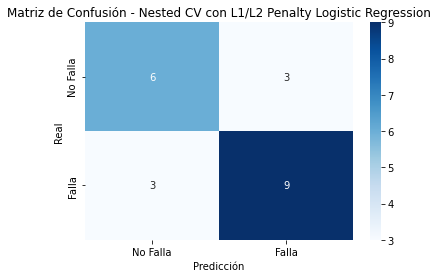

In [336]:
# Matriz de Confusión
conf_matrix = confusion_matrix(all_y_true, all_y_pred)

# Visualizar la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Falla", "Falla"], yticklabels=["No Falla", "Falla"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Nested CV con L1/L2 Penalty Logistic Regression")
plt.show()

In [337]:
# Mostrar resultados de Nested Cross-Validation
print("Nested CV Scores: ", nested_scores)
print("Mean Accuracy: {:.4f} ± {:.4f}".format(np.mean(nested_scores), np.std(nested_scores)))

# Métricas adicionales
print("Reporte de clasificación:\n", classification_report(all_y_true, all_y_pred))

Nested CV Scores:  [0.9333333333333332, 0.7071428571428572, 0.7146464646464645, 0.7579365079365079, 0.7936507936507936]
Mean Accuracy: 0.7813 ± 0.0822
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.67      0.67      0.67         9
           1       0.75      0.75      0.75        12

    accuracy                           0.71        21
   macro avg       0.71      0.71      0.71        21
weighted avg       0.71      0.71      0.71        21



#### Curva ROC y AUC

AUC Score: 0.7315


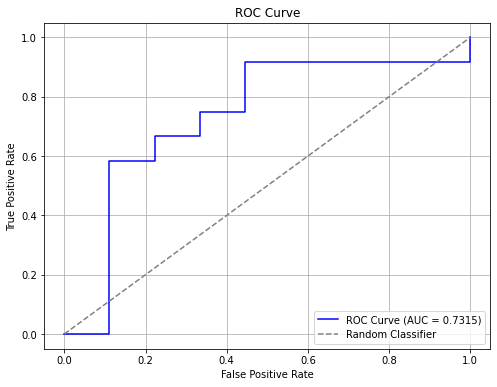

In [338]:
# Calcular AUC
auc_score = roc_auc_score(all_y_true, all_y_scores)
print(f"AUC Score: {auc_score:.4f}")

# Calcular puntos de la curva ROC
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_scores)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Modelo Random Forest 

En las siguientes lineas de codigos, aplicaremos el modelo de Random Forest.

#### Entrenamiento del modelo

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Crear pipeline con escalado y Random Forest
pipe = make_pipeline(StandardScaler(), RandomForestClassifier())

# Definir hiperparámetros para GridSearch
param_grid = {
    "randomforestclassifier__n_estimators": [100, 200, 300],  # Número de árboles
    "randomforestclassifier__max_depth": [10, 20, None],  # Profundidad del árbol
    "randomforestclassifier__min_samples_split": [2, 3, 4,5],  # Mínimos datos para dividir un nodo
    "randomforestclassifier__min_samples_leaf": [1, 2,3]  # Mínimos datos en una hoja
}

# Variables para guardar resultados
all_y_true = []
all_y_pred = []
all_y_scores = []
nested_scores = []
best_params_list = []  # Guardamos los mejores hiperparámetros en cada iteración
processing_times = []

# Diccionario para tiempos por tipo de algoritmo
algorithm_times = defaultdict(list)

# Iterar sobre los folds de la validación externa
for fold_idx, (train_idx, test_idx) in enumerate(cv_outer.split(X, y), 1):
    start_time = time.time()
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Aplicar SMOTE a los datos de entrenamiento
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Aplicar GridSearchCV dentro de cada fold
    grid_search = GridSearchCV(pipe, param_grid, cv=cv_inner, scoring="recall", n_jobs=-1)
    grid_search.fit(X_train_res, y_train_res)  

    # Guardar los mejores hiperparámetros de esta iteración
    best_params_list.append(frozenset(grid_search.best_params_.items()))

    # Obtener el mejor modelo y hacer predicciones en el conjunto de prueba
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_scores = best_model.predict_proba(X_test)[:, 1]  # Probabilidad de la clase positiva

    # Guardar resultados
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_scores.extend(y_scores)
    nested_scores.append(grid_search.best_score_)
    
             # Guardar tiempo por fold
    end_time = time.time()
    elapsed_time = end_time - start_time
    processing_times.append(elapsed_time)
    print(f"⏳ Tiempo total del fold {fold_idx}: {elapsed_time:.2f} segundos")

    # Medir tiempo promedio por tipo de algoritmo en GridSearch interna
    results = grid_search.cv_results_
    for mean_time, params in zip(results["mean_fit_time"], results["params"]):
        algorithm = params["randomforestclassifier__n_estimators"]
        algorithm_times[algorithm].append(mean_time)

⏳ Tiempo total del fold 1: 3.89 segundos
⏳ Tiempo total del fold 2: 4.01 segundos
⏳ Tiempo total del fold 3: 4.17 segundos
⏳ Tiempo total del fold 4: 3.99 segundos
⏳ Tiempo total del fold 5: 4.22 segundos


In [340]:
# Encontrar los hiperparámetros más frecuentes
best_overall_params = Counter(best_params_list).most_common(1)[0][0]
best_overall_params = dict(best_overall_params)  # Convertimos de nuevo a diccionario

# Tiempo promedio por tipo de algoritmo
print("\n📊 Tiempo promedio por tipo de algoritmo:")
for algorithm, times in algorithm_times.items():
    avg_time = sum(times) / len(times)
    print(f"🔧 '{algorithm}': {avg_time:.4f} segundos (promedio en {len(times)} ejecuciones)")

# Eliminamos los prefijos 
best_params = {k.replace("randomforestclassifier__", ""): v for k, v in best_overall_params.items()}

print("Mejores hiperparámetros globales:", best_params)


📊 Tiempo promedio por tipo de algoritmo:
🔧 '100': 0.0465 segundos (promedio en 180 ejecuciones)
🔧 '200': 0.0914 segundos (promedio en 180 ejecuciones)
🔧 '300': 0.1368 segundos (promedio en 180 ejecuciones)
Mejores hiperparámetros globales: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 10}


#### Matriz de Confusión y metricas de desempeno

Nested CV Scores:  [0.7746031746031745, 0.45714285714285713, 0.6309523809523809, 0.7666666666666666, 0.8412698412698413]
Mean Accuracy: 0.6941 ± 0.1368


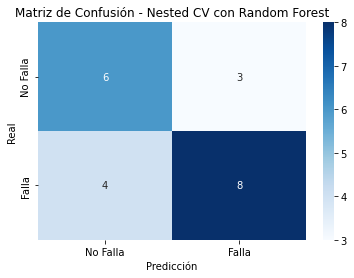

In [342]:
# Mostrar resultados de Nested Cross-Validation
print("Nested CV Scores: ", nested_scores)
print("Mean Accuracy: {:.4f} ± {:.4f}".format(np.mean(nested_scores), np.std(nested_scores)))

# Matriz de Confusión
conf_matrix = confusion_matrix(all_y_true, all_y_pred)

# Visualizar la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Falla", "Falla"], yticklabels=["No Falla", "Falla"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Nested CV con Random Forest")
plt.show()

In [343]:
# Mostrar resultados de Nested Cross-Validation
print("Nested CV Scores: ", nested_scores)
print("Mean Accuracy: {:.4f} ± {:.4f}".format(np.mean(nested_scores), np.std(nested_scores)))
# Métricas adicionales
print("Reporte de clasificación:\n", classification_report(all_y_true, all_y_pred))

Nested CV Scores:  [0.7746031746031745, 0.45714285714285713, 0.6309523809523809, 0.7666666666666666, 0.8412698412698413]
Mean Accuracy: 0.6941 ± 0.1368
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.60      0.67      0.63         9
           1       0.73      0.67      0.70        12

    accuracy                           0.67        21
   macro avg       0.66      0.67      0.66        21
weighted avg       0.67      0.67      0.67        21



#### Curva ROC y AUC

AUC Score: 0.6296


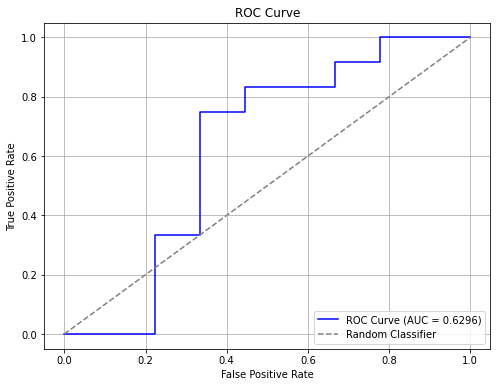

In [344]:
# Calcular AUC
auc_score = roc_auc_score(all_y_true, all_y_scores)
print(f"AUC Score: {auc_score:.4f}")

# Calcular puntos de la curva ROC
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_scores)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Modelo XGBoost

En las siguientes lineas de codigos, aplicaremos el modelo de XGBoost aplicando metodo de arbol *"Hist"*.

#### Entrenamiento del modelo - Tree method Hist()

In [ ]:
from xgboost import XGBClassifier  # Para clasificación

# Crear pipeline con escalado y XGBoost
pipe = make_pipeline(StandardScaler(), XGBClassifier())

# Definir hiperparámetros para GridSearch
param_grid = {
    'xgbclassifier__n_estimators': [100, 200,300,400],  
    'xgbclassifier__max_depth': [3, 6, 9,10],  
    'xgbclassifier__learning_rate': [0.01, 0.1, 0.2,0.5],  
    'xgbclassifier__colsample_bytree': [0.5, 0.8, 1.0],
    'xgbclassifier__tree_method': ['hist', 'exact',None]   
}

# Variables para guardar resultados
all_y_true = []
all_y_pred = []
all_y_scores = []
nested_scores = []
processing_times = []

# Diccionario para tiempos por tipo de algoritmo
algorithm_times = defaultdict(list)

# Iterar sobre los folds de la validación externa
for fold_idx, (train_idx, test_idx) in enumerate(cv_outer.split(X, y), 1):
    start_time = time.time()
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Aplicar SMOTE a los datos de entrenamiento
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Aplicar GridSearchCV dentro de cada fold
    grid_search = GridSearchCV(pipe, param_grid, cv=cv_inner, scoring="recall", n_jobs=-1)
    grid_search.fit(X_train_res, y_train_res)  

    # Guardar los mejores hiperparámetros de esta iteración
    best_params_list.append(frozenset(grid_search.best_params_.items()))

    # Obtener el mejor modelo y hacer predicciones en el conjunto de prueba
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_scores = best_model.predict_proba(X_test)[:, 1]  # Probabilidad de la clase positiva

    # Guardar resultados
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_scores.extend(y_scores)
    nested_scores.append(grid_search.best_score_)
    
             # Guardar tiempo por fold
    end_time = time.time()
    elapsed_time = end_time - start_time
    processing_times.append(elapsed_time)
    print(f"⏳ Tiempo total del fold {fold_idx}: {elapsed_time:.2f} segundos")

    # Medir tiempo promedio por tipo de algoritmo en GridSearch interna
    results = grid_search.cv_results_
    for mean_time, params in zip(results["mean_fit_time"], results["params"]):
        algorithm = params["xgbclassifier__tree_method"]
        algorithm_times[algorithm].append(mean_time)
        

⏳ Tiempo total del fold 1: 3.40 segundos
⏳ Tiempo total del fold 2: 3.26 segundos
⏳ Tiempo total del fold 3: 3.52 segundos
⏳ Tiempo total del fold 4: 3.46 segundos
⏳ Tiempo total del fold 5: 3.44 segundos


In [346]:

# Encontrar los hiperparámetros más frecuentes
best_overall_params = Counter(best_params_list).most_common(1)[0][0]
best_overall_params = dict(best_overall_params)  # Convertimos de nuevo a diccionario

# Tiempo promedio por tipo de algoritmo
print("\n📊 Tiempo promedio por tipo de algoritmo:")
for algorithm, times in algorithm_times.items():
    avg_time = sum(times) / len(times)
    print(f"🔧 '{algorithm}': {avg_time:.4f} segundos (promedio en {len(times)} ejecuciones)")

# Eliminamos los prefijos 
best_params = {k.replace("xgbclassifierr__", ""): v for k, v in best_overall_params.items()}

print("Mejores hiperparámetros globales:", best_params)


📊 Tiempo promedio por tipo de algoritmo:
🔧 'hist': 0.0133 segundos (promedio en 960 ejecuciones)
🔧 'exact': 0.0136 segundos (promedio en 960 ejecuciones)
🔧 'None': 0.0133 segundos (promedio en 960 ejecuciones)
Mejores hiperparámetros globales: {'randomforestclassifier__n_estimators': 100, 'randomforestclassifier__min_samples_split': 5, 'randomforestclassifier__min_samples_leaf': 2, 'randomforestclassifier__max_depth': 10}


#### Matriz de Confusión y metricas de desempeno

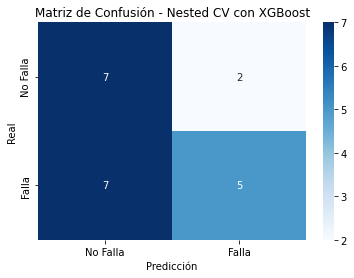

In [347]:
# Matriz de Confusión
conf_matrix = confusion_matrix(all_y_true, all_y_pred)

# Visualizar la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Falla", "Falla"], yticklabels=["No Falla", "Falla"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Nested CV con XGBoost")
plt.show()

In [243]:
# Mostrar resultados de Nested Cross-Validation
print("Nested CV Scores: ", nested_scores)
print("Mean Accuracy: {:.4f} ± {:.4f}".format(np.mean(nested_scores), np.std(nested_scores)))
# Métricas adicionales
print("Reporte de clasificación:\n", classification_report(all_y_true, all_y_pred))

Nested CV Scores:  [0.7777777777777777, 0.6666666666666666, 0.611111111111111, 0.8055555555555555, 0.7777777777777777]
Mean Accuracy: 0.7278 ± 0.0754
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.50      0.78      0.61         9
           1       0.71      0.42      0.53        12

    accuracy                           0.57        21
   macro avg       0.61      0.60      0.57        21
weighted avg       0.62      0.57      0.56        21



#### Curva ROC y AUC

AUC Score: 0.6111


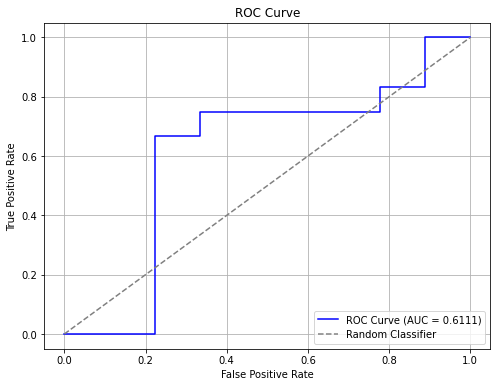

In [348]:
# Calcular AUC
auc_score = roc_auc_score(all_y_true, all_y_scores)
print(f"AUC Score: {auc_score:.4f}")

# Calcular puntos de la curva ROC
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_scores)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Modelo SVM (Support Vector Machines)

En las siguientes lineas de codigos, aplicaremos el modelo SVM con distntos Kernels para determinar cual es el mejor. 

#### Entrenamiento del modelo

In [ ]:
from sklearn.svm import SVC

# Crear pipeline con escalado y SVM
pipe = Pipeline([
    ('standardscaler', StandardScaler()),
    ('svc', SVC(probability=True))  
])

# Definir hiperparámetros para GridSearch
param_grid = {'svc__C': [0.001, 0.01, 0.1, 1, 10, 1000,0.0001], 
              'svc__gamma': [0.001, 0.01, 0.1, 1, 10, 100,0.0001],
              'svc__kernel': ['linear', 'rbf', 'poly', 'sigmoid']
              }

# Variables para guardar resultados
all_y_true = []
all_y_pred = []
all_y_scores = []
nested_scores = []
best_params_list = []  # Guardamos los mejores hiperparámetros en cada iteración
processing_times = []

# Diccionario para tiempos por tipo de algoritmo
algorithm_times = defaultdict(list)

# Iterar sobre los folds de la validación externa
for fold_idx, (train_idx, test_idx) in enumerate(cv_outer.split(X, y), 1):
    start_time = time.time()
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Aplicar SMOTE a los datos de entrenamiento
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Aplicar GridSearchCV dentro de cada fold
    grid_search = GridSearchCV(pipe, param_grid, cv=cv_inner, n_jobs=-1)
    grid_search.fit(X_train_res, y_train_res)  

    # Guardar los mejores hiperparámetros de esta iteración
    best_params_list.append(frozenset(grid_search.best_params_.items()))

    # Obtener el mejor modelo y hacer predicciones en el conjunto de prueba
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_scores = best_model.predict_proba(X_test)[:, 1]  # Probabilidad de la clase positiva

    # Guardar resultados
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_scores.extend(y_scores)
    nested_scores.append(grid_search.best_score_)
    
    # Guardar tiempo por fold
    end_time = time.time()
    elapsed_time = end_time - start_time
    processing_times.append(elapsed_time)
    print(f"⏳ Tiempo total del fold {fold_idx}: {elapsed_time:.2f} segundos")

    # Medir tiempo promedio por tipo de algoritmo en GridSearch interna
    results = grid_search.cv_results_
    for mean_time, params in zip(results["mean_fit_time"], results["params"]):
        algorithm = params["svc__kernel"]
        algorithm_times[algorithm].append(mean_time)


⏳ Tiempo total del fold 1: 0.31 segundos
⏳ Tiempo total del fold 2: 0.27 segundos
⏳ Tiempo total del fold 3: 0.28 segundos
⏳ Tiempo total del fold 4: 0.26 segundos
⏳ Tiempo total del fold 5: 0.30 segundos


In [351]:
# Encontrar los hiperparámetros más frecuentes
best_overall_params = Counter(best_params_list).most_common(1)[0][0]
best_overall_params = dict(best_overall_params)  # Convertimos de nuevo a diccionario

# Tiempo promedio por tipo de algoritmo
print("\n📊 Tiempo promedio por tipo de algoritmo:")
for algorithm, times in algorithm_times.items():
    avg_time = sum(times) / len(times)
    print(f"🔧 '{algorithm}': {avg_time:.4f} segundos (promedio en {len(times)} ejecuciones)")

# Eliminamos los prefijos 
best_params = {k.replace("svc__", ""): v for k, v in best_overall_params.items()}

print("Mejores hiperparámetros globales:", best_params)



📊 Tiempo promedio por tipo de algoritmo:
🔧 'linear': 0.0016 segundos (promedio en 245 ejecuciones)
🔧 'rbf': 0.0017 segundos (promedio en 245 ejecuciones)
🔧 'poly': 0.0018 segundos (promedio en 245 ejecuciones)
🔧 'sigmoid': 0.0015 segundos (promedio en 245 ejecuciones)
Mejores hiperparámetros globales: {'gamma': 0.1, 'C': 1, 'kernel': 'rbf'}


#### Matriz de Confusión y metricas de desempeno

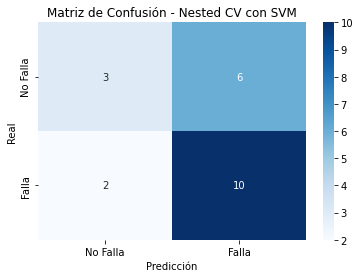

In [352]:
# Matriz de Confusión
conf_matrix = confusion_matrix(all_y_true, all_y_pred)

# Visualizar la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Falla", "Falla"], yticklabels=["No Falla", "Falla"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Nested CV con SVM")
plt.show()

In [353]:
# Evaluación final
print("Nested CV Scores: ", nested_scores)
print("Mean Accuracy: {:.4f} ± {:.4f}".format(np.mean(nested_scores), np.std(nested_scores)))
# Reporte de clasificación
print("Reporte de clasificación:\n", classification_report(all_y_true, all_y_pred))

Nested CV Scores:  [0.8857142857142858, 0.8055555555555555, 0.7857142857142857, 0.8677248677248678, 0.8888888888888888]
Mean Accuracy: 0.8467 ± 0.0428
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.60      0.33      0.43         9
           1       0.62      0.83      0.71        12

    accuracy                           0.62        21
   macro avg       0.61      0.58      0.57        21
weighted avg       0.61      0.62      0.59        21



#### Curva ROC y AUC

AUC Score: 0.5648


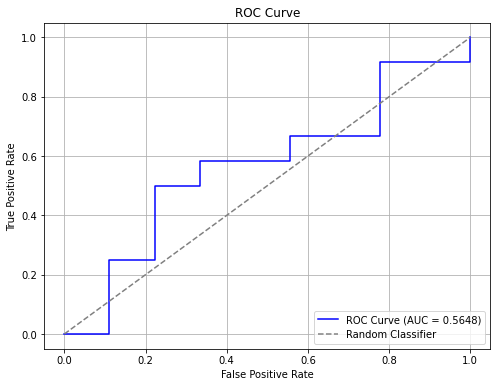

In [354]:
# Calcular AUC
auc_score = roc_auc_score(all_y_true, all_y_scores)
print(f"AUC Score: {auc_score:.4f}")

# Calcular puntos de la curva ROC
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_scores)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Modelo ANN (Redes Neuronales Artificiales)

En las siguientes lineas de codigos, aplicaremos el modelo de Redes neuronales aplicando el **Multi Layer Perceptron (MLP)** y evaluaremos los tiempos de optimizacion en funcion de la funcion del numero de capas ocultas.

In [ ]:
from sklearn.neural_network import MLPClassifier

# Crear pipeline con escalado y MLP
pipe = make_pipeline(StandardScaler(),  MLPClassifier(random_state=42, max_iter=10000000000))

# Definir hiperparámetros para GridSearch
param_grid = {
    'mlpclassifier__hidden_layer_sizes': [(5,), (10,), (15,), (20,)],  # Número de neuronas en las capas ocultas
    'mlpclassifier__activation': ['relu', 'tanh', 'logistic'],  # Función de activación
    'mlpclassifier__solver': ['adam', 'lbfgs'],  # Algoritmo de optimización
    'mlpclassifier__alpha': [0.0001, 0.001, 0.01],  # Parámetro de regularización L2
    'mlpclassifier__learning_rate': ['constant', 'adaptive'],  # Estrategia de tasa de aprendizaje
}

# Variables para guardar resultados
all_y_true = []
all_y_pred = []
all_y_scores = []
nested_scores = []
best_params_list = []  # Guardamos los mejores hiperparámetros en cada iteración
processing_times = []

# Diccionario para tiempos por tipo de algoritmo
algorithm_times = defaultdict(list)

# Iterar sobre los folds de la validación externa
for fold_idx, (train_idx, test_idx) in enumerate(cv_outer.split(X, y), 1):
    start_time = time.time()
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Aplicar SMOTE a los datos de entrenamiento
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Aplicar GridSearchCV dentro de cada fold
    grid_search = GridSearchCV(pipe, param_grid, cv=cv_inner, scoring="recall", n_jobs=-1)
    grid_search.fit(X_train_res, y_train_res)  

    # Guardar los mejores hiperparámetros de esta iteración
    best_params_list.append(frozenset(grid_search.best_params_.items()))

    # Obtener el mejor modelo y hacer predicciones en el conjunto de prueba
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_scores = best_model.predict_proba(X_test)[:, 1]  # Probabilidad de la clase positiva

    # Guardar resultados
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_scores.extend(y_scores)
    nested_scores.append(grid_search.best_score_)
    
    # Guardar tiempo por fold
    end_time = time.time()
    elapsed_time = end_time - start_time
    processing_times.append(elapsed_time)
    print(f"⏳ Tiempo total del fold {fold_idx}: {elapsed_time:.2f} segundos")

    # Medir tiempo promedio por tipo de algoritmo en GridSearch interna
    results = grid_search.cv_results_
    for mean_time, params in zip(results["mean_fit_time"], results["params"]):
        algorithm = params["mlpclassifier__hidden_layer_sizes"]
        algorithm_times[algorithm].append(mean_time)




⏳ Tiempo total del fold 1: 2.89 segundos
⏳ Tiempo total del fold 2: 3.24 segundos
⏳ Tiempo total del fold 3: 3.35 segundos
⏳ Tiempo total del fold 4: 3.23 segundos
⏳ Tiempo total del fold 5: 2.94 segundos


In [356]:
# Encontrar los hiperparámetros más frecuentes
best_overall_params = Counter(best_params_list).most_common(1)[0][0]
best_overall_params = dict(best_overall_params)  # Convertimos de nuevo a diccionario

# Tiempo promedio por tipo de algoritmo
print("\n📊 Tiempo promedio por tipo de algoritmo:")
for algorithm, times in algorithm_times.items():
    avg_time = sum(times) / len(times)
    print(f"🔧 '{algorithm}': {avg_time:.4f} segundos (promedio en {len(times)} ejecuciones)")

# Eliminamos los prefijos
best_params = {k.replace("mlpclassifier__", ""): v for k, v in best_overall_params.items()}

print("Mejores hiperparámetros globales:", best_params)


📊 Tiempo promedio por tipo de algoritmo:
🔧 '(5,)': 0.0717 segundos (promedio en 180 ejecuciones)
🔧 '(10,)': 0.0536 segundos (promedio en 180 ejecuciones)
🔧 '(15,)': 0.0449 segundos (promedio en 180 ejecuciones)
🔧 '(20,)': 0.0427 segundos (promedio en 180 ejecuciones)
Mejores hiperparámetros globales: {'learning_rate': 'constant', 'solver': 'lbfgs', 'alpha': 0.01, 'hidden_layer_sizes': (15,), 'activation': 'relu'}


#### Matriz de Confusión y metricas de desempeno

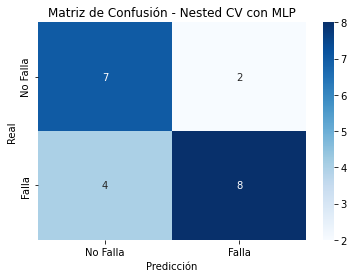

In [357]:
# Matriz de Confusión
conf_matrix = confusion_matrix(all_y_true, all_y_pred)

# Visualizar la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Falla", "Falla"], yticklabels=["No Falla", "Falla"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Nested CV con MLP")
plt.show()

In [358]:
# Evaluación final
print("Nested CV Scores: ", nested_scores)
print("Mean Accuracy: {:.4f} ± {:.4f}".format(np.mean(nested_scores), np.std(nested_scores)))
# Reporte de clasificación
print("Reporte de clasificación:\n", classification_report(all_y_true, all_y_pred))

Nested CV Scores:  [0.9333333333333332, 0.7746031746031746, 0.7746031746031745, 0.7666666666666666, 0.8412698412698413]
Mean Accuracy: 0.8181 ± 0.0636
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.64      0.78      0.70         9
           1       0.80      0.67      0.73        12

    accuracy                           0.71        21
   macro avg       0.72      0.72      0.71        21
weighted avg       0.73      0.71      0.72        21



#### Curva ROC y metrica AUC

AUC Score: 0.7315


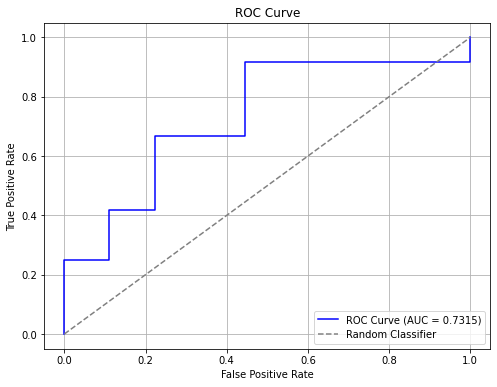

In [359]:
# Calcular AUC
auc_score = roc_auc_score(all_y_true, all_y_scores)
print(f"AUC Score: {auc_score:.4f}")

# Calcular puntos de la curva ROC
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_scores)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Resultados 

Observamos los resultados de todos los modelos 

In [315]:
import pandas as pd

# Lista de modelos
modelos = [
    "KNN",
    "Naive Bayes",
    "LogReg (L2)",
    "Random Forest",
    "XGBoost",
    "SVM",
    "ANN MLP"
]

# Inicializamos el DataFrame
metricas = ["Precision", "Recall", "F1-score", "Accuracy", "AUC"]
tabla_resultados = pd.DataFrame(index=modelos, columns=metricas)

# Ejemplo: llenado de una fila (cuando tengas resultados)
tabla_resultados.loc["KNN"] = [0.67, 0.50, 0.57, 0.57, 0.73]
tabla_resultados.loc["Naive Bayes"] = [0.73, 0.92, 0.81, 0.76, 0.52]
tabla_resultados.loc["LogReg (L2)"] = [0.77, 0.83, 0.80, 0.76, 0.75]
tabla_resultados.loc["Random Forest"] = [0.70, 0.58, 0.64, 0.62, 0.62]
tabla_resultados.loc["XGBoost"] = [0.71, 0.42, 0.53, 0.57, 0.61]
tabla_resultados.loc["SVM"] = [0.67, 0.83, 0.74, 0.67, 0.67]
tabla_resultados.loc["ANN MLP"] = [0.75, 0.75, 0.75, 0.71, 0.73]

print(tabla_resultados)

              Precision Recall F1-score Accuracy   AUC
KNN                0.67    0.5     0.57     0.57  0.73
Naive Bayes        0.73   0.92     0.81     0.76  0.52
LogReg (L2)        0.77   0.83      0.8     0.76  0.75
Random Forest       0.7   0.58     0.64     0.62  0.62
XGBoost            0.71   0.42     0.53     0.57  0.61
SVM                0.67   0.83     0.74     0.67  0.67
ANN MLP            0.75   0.75     0.75     0.71  0.73
